In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"D:\User(D)\Download\Mall_Customers.csv")
print(data.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [6]:
# STEP 2: Generate Realistic Mall Customer Dataset
np.random.seed(42)
N = 200

# Segment-based generation (5 natural clusters in the data)
segments = {
    "Young Spenders":        {"n": 40, "age": (20,30), "income": (15,40),  "score": (60,100)},
    "Wealthy Conservatives": {"n": 40, "age": (35,55), "income": (70,140), "score": (1,40)},
    "Middle Class Balanced": {"n": 40, "age": (30,50), "income": (40,80),  "score": (40,70)},
    "Low Income Low Spend":  {"n": 40, "age": (25,70), "income": (15,40),  "score": (1,40)},
    "High Income High Spend":{"n": 40, "age": (25,45), "income": (70,140), "score": (65,100)},
}

rows = []
true_labels = []
for seg_name, cfg in segments.items():
    n = cfg["n"]
    age    = np.random.randint(*cfg["age"],   n)
    income = np.random.randint(*cfg["income"],n)
    score  = np.random.randint(*cfg["score"], n)
    gender = np.random.choice(["Male","Female"], n)
    for i in range(n):
        rows.append({"CustomerID": len(rows)+1,
                     "Gender": gender[i],
                     "Age": age[i],
                     "Annual Income (k$)": income[i],
                     "Spending Score (1-100)": score[i]})
        true_labels.append(seg_name)

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\n✅ Dataset created: {df.shape[0]} customers × {df.shape[1]} features")


✅ Dataset created: 200 customers × 5 features


In [7]:
# STEP 3: Exploratory Data Analysis
print("\n" + "─"*45)
print("STEP 3 — EXPLORATORY DATA ANALYSIS")
print("─"*45)

print("\n📋 First 5 rows:")
print(df.head().to_string(index=False))

print("\n📊 Dataset Info:")
print(f"   Shape       : {df.shape}")
print(f"   Missing vals: {df.isnull().sum().sum()}")
print(f"   Duplicates  : {df.duplicated().sum()}")

print("\n📈 Descriptive Statistics:")
print(df.describe().round(2).to_string())

print("\n👥 Gender Distribution:")
print(df["Gender"].value_counts().to_string())


─────────────────────────────────────────────
STEP 3 — EXPLORATORY DATA ANALYSIS
─────────────────────────────────────────────

📋 First 5 rows:
 CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
         96 Female   30                  61                      61
         16 Female   24                  18                      76
         31   Male   28                  28                      83
        159 Female   31                  36                      27
        129   Male   36                  39                      14

📊 Dataset Info:
   Shape       : (200, 5)
   Missing vals: 0
   Duplicates  : 0

📈 Descriptive Statistics:
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   37.92               65.06                   52.00
std         57.88   10.95               37.96                   29.38
min          1.00   20.00               16.00              


─────────────────────────────────────────────
STEP 4 — EDA VISUALIZATIONS
─────────────────────────────────────────────


C:\Users\Hp\AppData\Local\Temp\ipykernel_23324\942980100.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y="Spending Score (1-100)", ax=ax6,
C:\Users\Hp\AppData\Local\Temp\ipykernel_23324\942980100.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Gender", y="Age", ax=ax9,


Text(0.5, 1.01, 'Mall Customer Dataset — Exploratory Data Analysis')

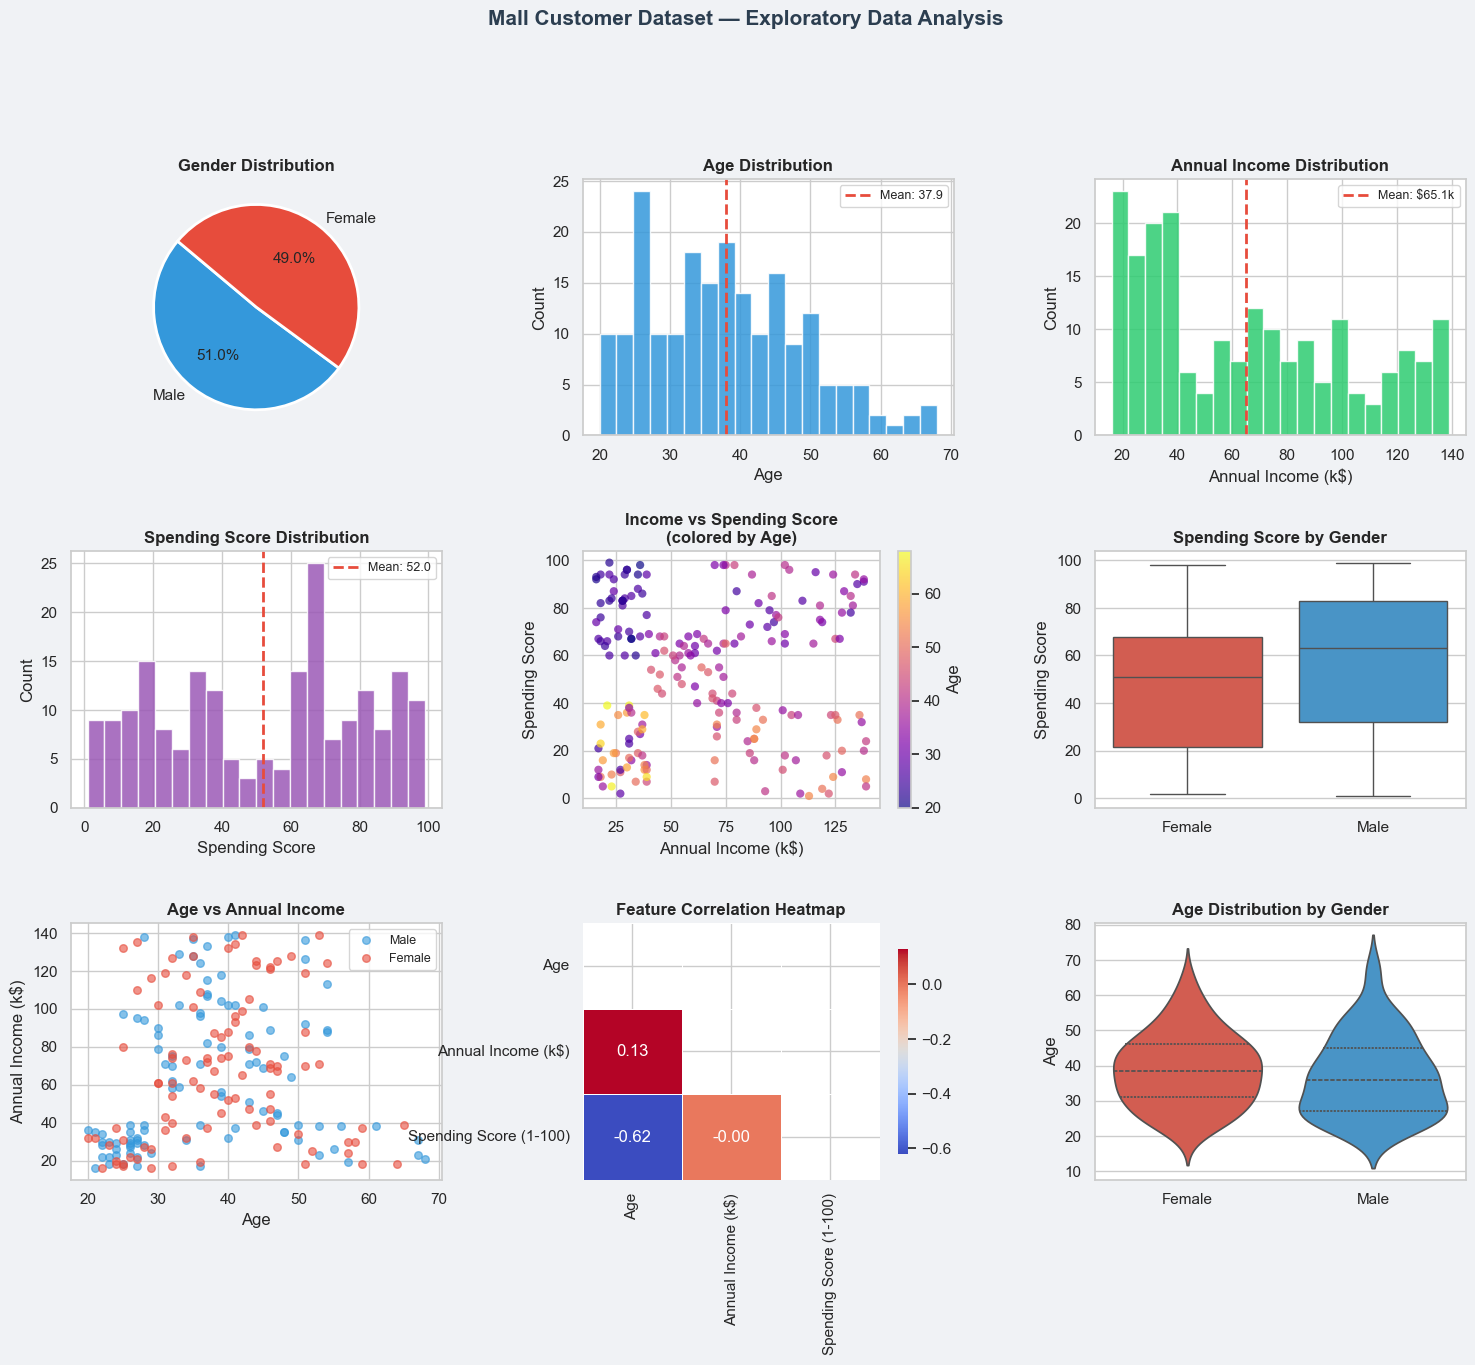

In [23]:
# STEP 4: EDA Visualizations
print("\n" + "─"*45)
print("STEP 4 — EDA VISUALIZATIONS")
print("─"*45)

PALETTE = ["#E74C3C","#3498DB","#2ECC71","#F39C12","#9B59B6"]
sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#F0F2F5")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1. Gender Pie
ax1 = fig.add_subplot(gs[0, 0])
gc = df["Gender"].value_counts()
ax1.pie(gc, labels=gc.index, autopct="%1.1f%%",
        colors=["#3498DB","#E74C3C"], startangle=140,
        textprops={"fontsize":11}, wedgeprops={"edgecolor":"white","linewidth":2})
ax1.set_title("Gender Distribution", fontweight="bold", fontsize=12)

# 2. Age Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df["Age"], bins=20, color="#3498DB", edgecolor="white", alpha=0.85)
ax2.axvline(df["Age"].mean(), color="#E74C3C", linestyle="--", linewidth=2, label=f"Mean: {df['Age'].mean():.1f}")
ax2.set_title("Age Distribution", fontweight="bold", fontsize=12)
ax2.set_xlabel("Age"); ax2.set_ylabel("Count")
ax2.legend(fontsize=9)

# 3. Income Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df["Annual Income (k$)"], bins=20, color="#2ECC71", edgecolor="white", alpha=0.85)
ax3.axvline(df["Annual Income (k$)"].mean(), color="#E74C3C", linestyle="--", linewidth=2,
            label=f"Mean: ${df['Annual Income (k$)'].mean():.1f}k")
ax3.set_title("Annual Income Distribution", fontweight="bold", fontsize=12)
ax3.set_xlabel("Annual Income (k$)"); ax3.set_ylabel("Count")
ax3.legend(fontsize=9)

# 4. Spending Score Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df["Spending Score (1-100)"], bins=20, color="#9B59B6", edgecolor="white", alpha=0.85)
ax4.axvline(df["Spending Score (1-100)"].mean(), color="#E74C3C", linestyle="--",
            linewidth=2, label=f"Mean: {df['Spending Score (1-100)'].mean():.1f}")
ax4.set_title("Spending Score Distribution", fontweight="bold", fontsize=12)
ax4.set_xlabel("Spending Score"); ax4.set_ylabel("Count")
ax4.legend(fontsize=9)

# 5. Income vs Spending Score (raw, no labels)
ax5 = fig.add_subplot(gs[1, 1])
sc = ax5.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
                 c=df["Age"], cmap="plasma", alpha=0.7, s=35, edgecolors="none")
plt.colorbar(sc, ax=ax5, label="Age")
ax5.set_title("Income vs Spending Score\n(colored by Age)", fontweight="bold", fontsize=12)
ax5.set_xlabel("Annual Income (k$)"); ax5.set_ylabel("Spending Score")

# 6. Gender vs Spending Score (box)
ax6 = fig.add_subplot(gs[1, 2])
sns.boxplot(data=df, x="Gender", y="Spending Score (1-100)", ax=ax6,
            palette={"Male":"#3498DB","Female":"#E74C3C"})
ax6.set_title("Spending Score by Gender", fontweight="bold", fontsize=12)
ax6.set_xlabel(""); ax6.set_ylabel("Spending Score")

# 7. Age vs Income scatter
ax7 = fig.add_subplot(gs[2, 0])
male = df[df["Gender"]=="Male"]; female = df[df["Gender"]=="Female"]
ax7.scatter(male["Age"], male["Annual Income (k$)"],   color="#3498DB", alpha=0.6, s=30, label="Male")
ax7.scatter(female["Age"], female["Annual Income (k$)"], color="#E74C3C", alpha=0.6, s=30, label="Female")
ax7.set_title("Age vs Annual Income", fontweight="bold", fontsize=12)
ax7.set_xlabel("Age"); ax7.set_ylabel("Annual Income (k$)")
ax7.legend(fontsize=9)

# 8. Correlation Heatmap
ax8 = fig.add_subplot(gs[2, 1])
num_df = df[["Age","Annual Income (k$)","Spending Score (1-100)"]]
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax8,
            linewidths=0.5, cbar_kws={"shrink":0.8},
            mask=np.triu(np.ones_like(corr, dtype=bool)))
ax8.set_title("Feature Correlation Heatmap", fontweight="bold", fontsize=12)

# 9. Violin: Age by Gender
ax9 = fig.add_subplot(gs[2, 2])
sns.violinplot(data=df, x="Gender", y="Age", ax=ax9,
               palette={"Male":"#3498DB","Female":"#E74C3C"}, inner="quartile")
ax9.set_title("Age Distribution by Gender", fontweight="bold", fontsize=12)
ax9.set_xlabel(""); ax9.set_ylabel("Age")

plt.suptitle("Mall Customer Dataset — Exploratory Data Analysis",
             fontsize=15, fontweight="bold", y=1.01, color="#2C3E50")
# plt.savefig("/mnt/user-data/outputs/01_eda_visualizations.png",
#             dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
# plt.close()
# print("✅ EDA plot saved → 01_eda_visualizations.png")

In [9]:
# STEP 5: Preprocessing — Scale Features
print("\n" + "─"*45)
print("STEP 5 — FEATURE SCALING")
print("─"*45)

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"   Features used : {features}")
print(f"   Scaled shape  : {X_scaled.shape}")
print(f"   Scaled mean   ≈ {X_scaled.mean(axis=0).round(4)}")
print(f"   Scaled std    ≈ {X_scaled.std(axis=0).round(4)}")


─────────────────────────────────────────────
STEP 5 — FEATURE SCALING
─────────────────────────────────────────────
   Features used : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   Scaled shape  : (200, 3)
   Scaled mean   ≈ [-0.  0. -0.]
   Scaled std    ≈ [1. 1. 1.]



─────────────────────────────────────────────
STEP 6 — OPTIMAL K (ELBOW + SILHOUETTE)
─────────────────────────────────────────────


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 


   K  |  Inertia   | Silhouette
  ----|------------|------------
   2  |    354.45  |   0.3633
   3  |    259.00  |   0.3517
   4  |    187.93  |   0.3772
   5  |    135.15  |   0.4256 ◄ BEST
   6  |    106.92  |   0.4446
   7  |     94.48  |   0.4052
   8  |     86.00  |   0.3865
   9  |     79.32  |   0.3733
   10  |     71.05  |   0.3637


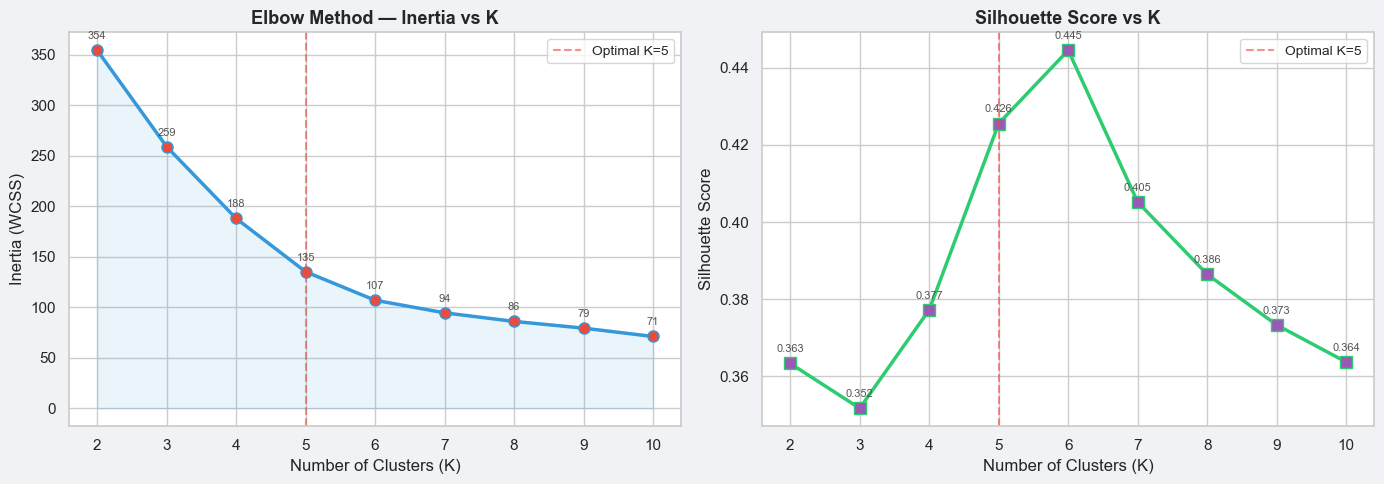

In [22]:
# STEP 6: Elbow Method + Silhouette Score → Find Optimal K
print("\n" + "─"*45)
print("STEP 6 — OPTIMAL K (ELBOW + SILHOUETTE)")
print("─"*45)

inertia    = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#F0F2F5")

# Elbow
axes[0].plot(K_range, inertia, marker="o", color="#3498DB", linewidth=2.5,
             markersize=8, markerfacecolor="#E74C3C")
axes[0].axvline(5, color="#E74C3C", linestyle="--", alpha=0.6, label="Optimal K=5")
axes[0].fill_between(K_range, inertia, alpha=0.1, color="#3498DB")
axes[0].set_title("Elbow Method — Inertia vs K", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Number of Clusters (K)"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].legend(fontsize=10)
for k, v in zip(K_range, inertia):
    axes[0].annotate(f"{v:.0f}", (k, v), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8, color="#555")

# Silhouette
axes[1].plot(K_range, sil_scores, marker="s", color="#2ECC71", linewidth=2.5,
             markersize=8, markerfacecolor="#9B59B6")
axes[1].axvline(5, color="#E74C3C", linestyle="--", alpha=0.6, label="Optimal K=5")
axes[1].set_title("Silhouette Score vs K", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Number of Clusters (K)"); axes[1].set_ylabel("Silhouette Score")
axes[1].legend(fontsize=10)
for k, v in zip(K_range, sil_scores):
    axes[1].annotate(f"{v:.3f}", (k, v), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8, color="#555")

print("\n   K  |  Inertia   | Silhouette")
print("  ----|------------|------------")
for k, ine, sil in zip(K_range, inertia, sil_scores):
    marker = " ◄ BEST" if k == 5 else ""
    print(f"   {k}  | {ine:9.2f}  |   {sil:.4f}{marker}")

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/02_elbow_silhouette.png",
#             dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
# plt.close()
# print("\n✅ Elbow/Silhouette plot saved → 02_elbow_silhouette.png")

In [11]:
# STEP 7: Apply K-Means with K=5
print("\n" + "─"*45)
print("STEP 7 — K-MEANS CLUSTERING  (K = 5)")
print("─"*45)

OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
final_sil = silhouette_score(X_scaled, df["Cluster"])

print(f"\n   Final Silhouette Score : {final_sil:.4f}")
print(f"   Inertia (WCSS)         : {kmeans.inertia_:.2f}")
print("\n   Cluster sizes:")
print(df["Cluster"].value_counts().sort_index().rename("Count").to_string())

# Cluster profiles
profile = df.groupby("Cluster")[features].mean().round(2)
profile["Count"] = df.groupby("Cluster").size()
print("\n   Cluster Profiles (mean values):")
print(profile.to_string())

# Assign human-readable segment names based on income/spending
SEGMENT_NAMES = {
    0: " High Income · High Spend   (Premium)",
    1: " Mid Income  · Mid Spend    (Balanced)",
    2: " Low Income  · High Spend   (Young Spender)",
    3: " High Income · Low Spend    (Conservative)",
    4: "  Low Income  · Low Spend   (Budget Seeker)",
}

# Sort clusters by (income + score) to auto-assign names
rank_order = profile[["Annual Income (k$)","Spending Score (1-100)"]].sum(axis=1).sort_values(ascending=False)
sorted_idx = rank_order.index.tolist()
# Build a mapping: richest+highest spend → Premium, etc.
AUTO_NAMES = [
    " High Income · High Spend   (Premium)",
    " High Income · Low Spend    (Conservative)",
    " Mid Income  · Mid Spend    (Balanced)",
    " Low Income  · High Spend   (Young Spender)",
    "  Low Income  · Low Spend   (Budget Seeker)",
]
SEGMENT_MAP = {cluster_id: name for cluster_id, name in zip(sorted_idx, AUTO_NAMES)}
df["Segment"] = df["Cluster"].map(SEGMENT_MAP)

print("\n   Segment assignments:")
for cid, name in SEGMENT_MAP.items():
    print(f"     Cluster {cid} → {name}")



─────────────────────────────────────────────
STEP 7 — K-MEANS CLUSTERING  (K = 5)
─────────────────────────────────────────────

   Final Silhouette Score : 0.4256
   Inertia (WCSS)         : 135.15

   Cluster sizes:


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster
0    57
1    41
2    35
3    40
4    27

   Cluster Profiles (mean values):
           Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                          
0        37.58               52.42                   45.02     57
1        24.83               26.98                   80.37     41
2        44.80              108.83                   20.71     35
3        33.90              105.82                   81.85     40
4        55.56               32.48                   20.04     27

   Segment assignments:
     Cluster 3 →  High Income · High Spend   (Premium)
     Cluster 2 →  High Income · Low Spend    (Conservative)
     Cluster 1 →  Mid Income  · Mid Spend    (Balanced)
     Cluster 0 →  Low Income  · High Spend   (Young Spender)
     Cluster 4 →   Low Income  · Low Spend   (Budget Seeker)



─────────────────────────────────────────────
STEP 8 — CLUSTER VISUALIZATION
─────────────────────────────────────────────


C:\Users\Hp\AppData\Local\Temp\ipykernel_23324\136490088.py:37: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Hp\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\Hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


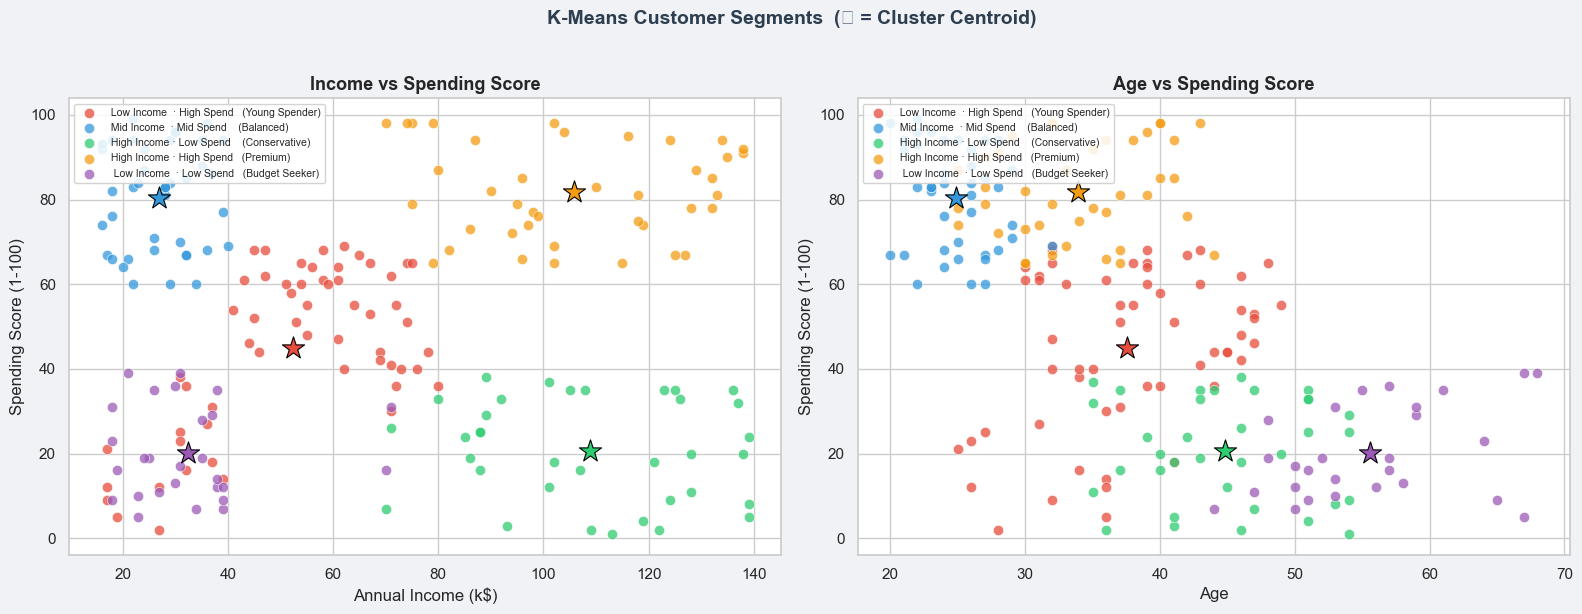

In [17]:
# STEP 8: Cluster Visualization (Income vs Spending, 2-feature)
print("\n" + "─"*45)
print("STEP 8 — CLUSTER VISUALIZATION")
print("─"*45)

CLUSTER_COLORS = ["#E74C3C","#3498DB","#2ECC71","#F39C12","#9B59B6"]
SEG_LABELS = [SEGMENT_MAP[i] for i in range(OPTIMAL_K)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#F0F2F5")

for ax, (xcol, ycol, title) in zip(axes, [
    ("Annual Income (k$)", "Spending Score (1-100)", "Income vs Spending Score"),
    ("Age",                "Spending Score (1-100)", "Age vs Spending Score"),
]):
    for cid in range(OPTIMAL_K):
        mask = df["Cluster"] == cid
        ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                   color=CLUSTER_COLORS[cid], alpha=0.75, s=55,
                   edgecolors="white", linewidths=0.5,
                   label=SEGMENT_MAP[cid])
    # Plot centroids
    cents_orig = scaler.inverse_transform(kmeans.cluster_centers_)
    for cid in range(OPTIMAL_K):
        xi = features.index(xcol)
        yi = features.index(ycol)
        ax.scatter(cents_orig[cid, xi], cents_orig[cid, yi],
                   marker="*", s=280, color=CLUSTER_COLORS[cid],
                   edgecolors="black", linewidths=0.8, zorder=5)

    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    ax.legend(fontsize=7.5, loc="upper left", framealpha=0.85)

plt.suptitle("K-Means Customer Segments  (★ = Cluster Centroid)",
             fontsize=14, fontweight="bold", y=1.02, color="#2C3E50")
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/03_kmeans_clusters.png",
#             dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
# plt.close()
# print("✅ Cluster plot saved → 03_kmeans_clusters.png")

In [15]:
# STEP 9: PCA — Dimensionality Reduction Visualization
print("\n" + "─"*45)
print("STEP 9 — PCA VISUALIZATION")
print("─"*45)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_

print(f"\n   PCA Explained Variance:")
print(f"     PC1 : {ev[0]*100:.2f}%")
print(f"     PC2 : {ev[1]*100:.2f}%")
print(f"     Total: {sum(ev)*100:.2f}%")
print(f"\n   PCA Component Loadings:")
pca_loadings = pd.DataFrame(pca.components_, columns=features,
                             index=["PC1","PC2"]).round(4)
print(pca_loadings.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#F0F2F5")

# PCA scatter
for cid in range(OPTIMAL_K):
    mask = df["Cluster"] == cid
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=CLUSTER_COLORS[cid], alpha=0.75, s=55,
                    edgecolors="white", linewidths=0.5,
                    label=SEGMENT_MAP[cid])
axes[0].set_title(f"PCA — 2D Cluster View\n(Explained variance: {sum(ev)*100:.1f}%)",
                  fontweight="bold", fontsize=13)
axes[0].set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
axes[0].legend(fontsize=7.5, framealpha=0.85)

# PCA biplot (loadings arrows)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=[CLUSTER_COLORS[c] for c in df["Cluster"]], alpha=0.5, s=35)
scale = 2.5
for i, feat in enumerate(features):
    axes[1].annotate("", xy=(pca.components_[0, i]*scale, pca.components_[1, i]*scale),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color="#E74C3C", lw=2.2))
    axes[1].text(pca.components_[0, i]*scale*1.12, pca.components_[1, i]*scale*1.12,
                 feat, fontsize=10, fontweight="bold", color="#2C3E50",
                 ha="center", va="center")
axes[1].set_title("PCA Biplot — Feature Loadings", fontweight="bold", fontsize=13)
axes[1].set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); axes[1].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
axes[1].axhline(0, color="gray", lw=0.5, ls="--")
axes[1].axvline(0, color="gray", lw=0.5, ls="--")

plt.suptitle("Principal Component Analysis (PCA)", fontsize=14,
             fontweight="bold", y=1.02, color="#2C3E50")
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/04_pca_visualization.png",
#             dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
# print("✅ PCA plot saved → 04_pca_visualization.png")


─────────────────────────────────────────────
STEP 9 — PCA VISUALIZATION
─────────────────────────────────────────────

   PCA Explained Variance:
     PC1 : 54.50%
     PC2 : 33.31%
     Total: 87.81%

   PCA Component Loadings:
        Age  Annual Income (k$)  Spending Score (1-100)
PC1  0.7069              0.1471                 -0.6918
PC2 -0.0021              0.9786                  0.2059



─────────────────────────────────────────────
STEP 10 — t-SNE VISUALIZATION
─────────────────────────────────────────────
   t-SNE output shape: (200, 2)


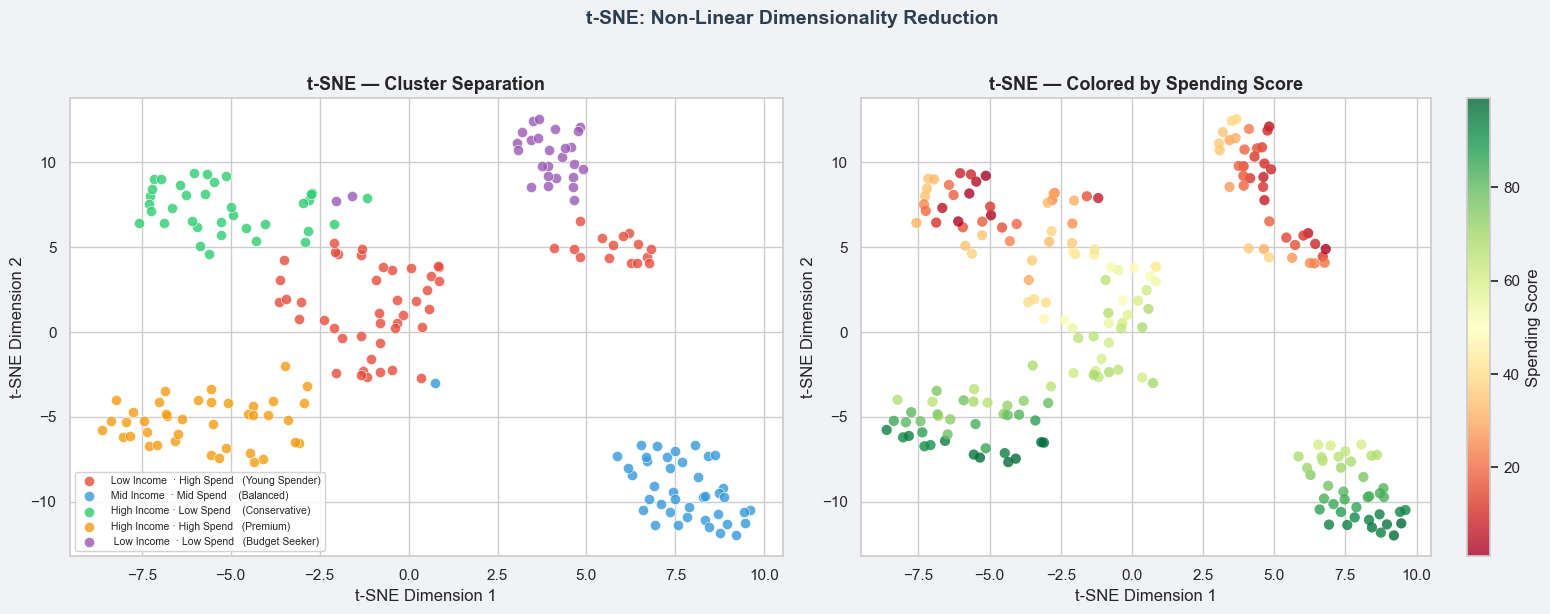

In [18]:
# STEP 10: t-SNE — Non-Linear Visualization
print("\n" + "─"*45)
print("STEP 10 — t-SNE VISUALIZATION")
print("─"*45)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print(f"   t-SNE output shape: {X_tsne.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#F0F2F5")

# t-SNE by cluster
for cid in range(OPTIMAL_K):
    mask = df["Cluster"] == cid
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    color=CLUSTER_COLORS[cid], alpha=0.8, s=55,
                    edgecolors="white", linewidths=0.5,
                    label=SEGMENT_MAP[cid])
axes[0].set_title("t-SNE — Cluster Separation", fontweight="bold", fontsize=13)
axes[0].set_xlabel("t-SNE Dimension 1"); axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].legend(fontsize=7.5, framealpha=0.85)

# t-SNE colored by Spending Score
sc = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                     c=df["Spending Score (1-100)"], cmap="RdYlGn",
                     alpha=0.8, s=55, edgecolors="none")
plt.colorbar(sc, ax=axes[1], label="Spending Score")
axes[1].set_title("t-SNE — Colored by Spending Score", fontweight="bold", fontsize=13)
axes[1].set_xlabel("t-SNE Dimension 1"); axes[1].set_ylabel("t-SNE Dimension 2")

plt.suptitle("t-SNE: Non-Linear Dimensionality Reduction", fontsize=14,
             fontweight="bold", y=1.02, color="#2C3E50")
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/05_tsne_visualization.png",
#             dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
# plt.close()
# print("✅ t-SNE plot saved → 05_tsne_visualization.png")


─────────────────────────────────────────────
STEP 11 — CLUSTER PROFILE DASHBOARD
─────────────────────────────────────────────


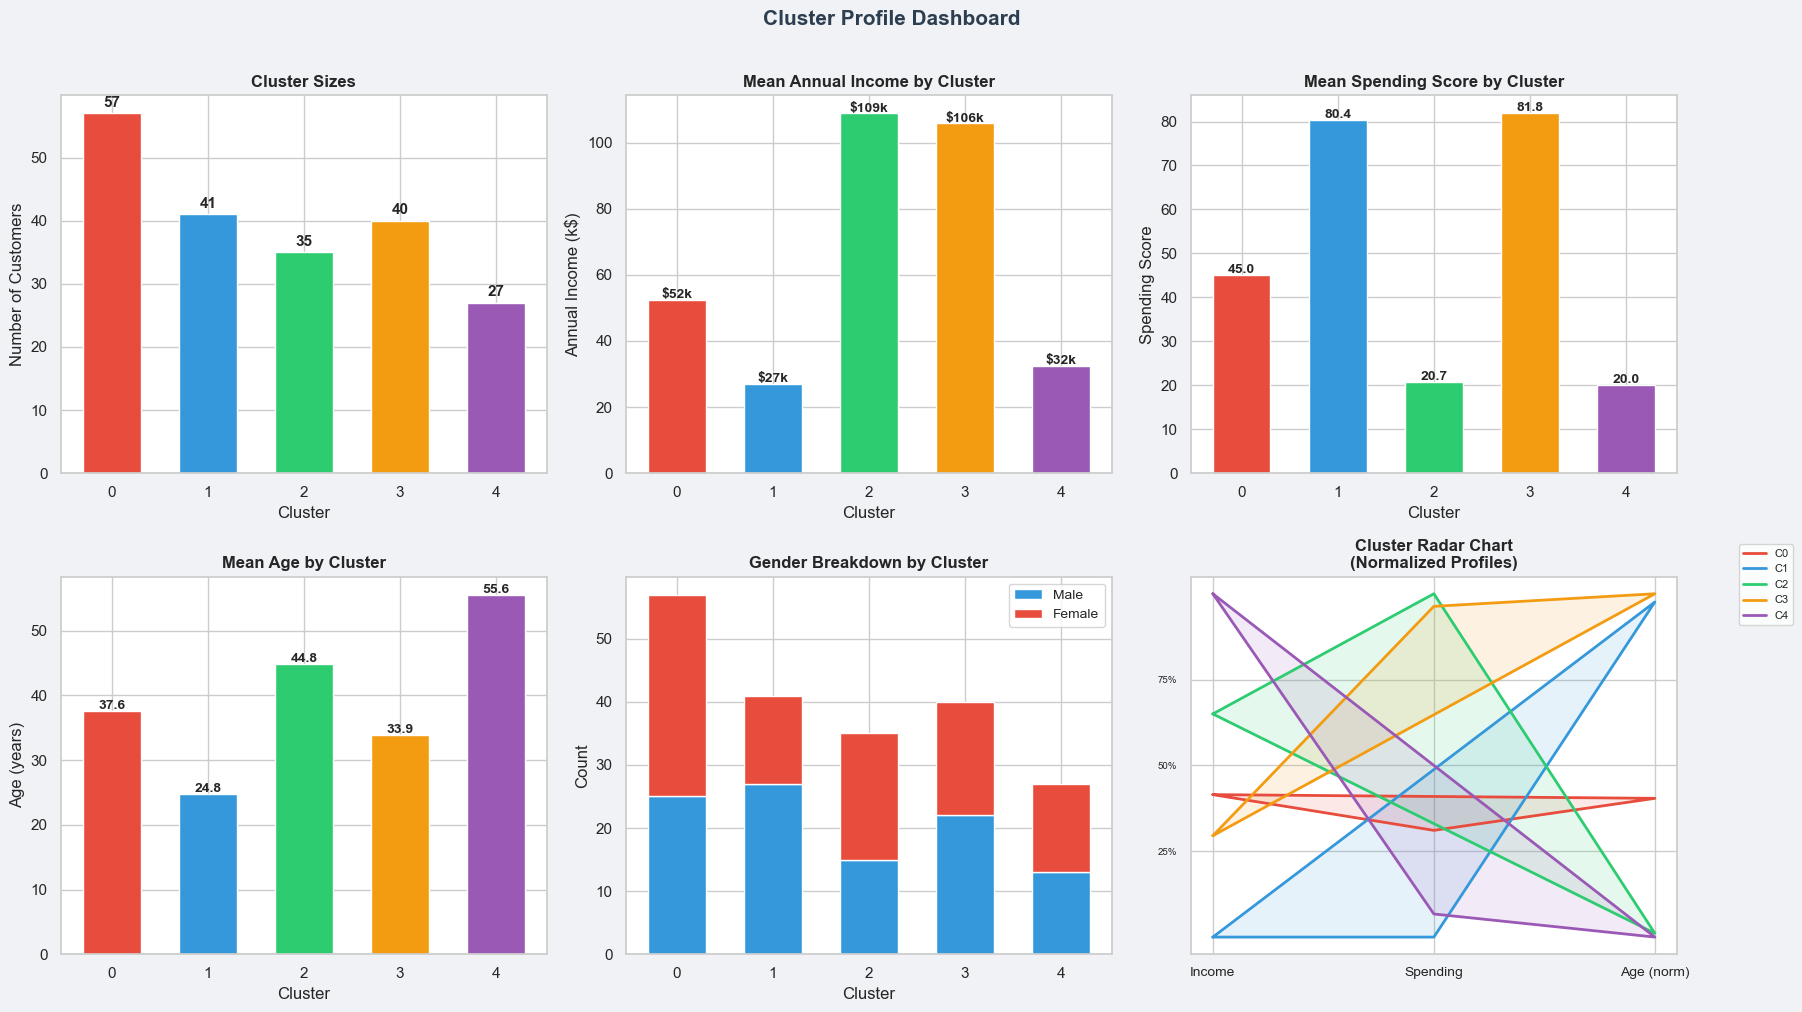

In [19]:
# STEP 11: Cluster Profile Deep-Dive Dashboard
print("\n" + "─"*45)
print("STEP 11 — CLUSTER PROFILE DASHBOARD")
print("─"*45)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#F0F2F5")
axes = axes.flatten()

# 11a. Cluster size bar
sizes = df.groupby("Cluster").size()
bars  = axes[0].bar(range(OPTIMAL_K), sizes, color=CLUSTER_COLORS, edgecolor="white", width=0.6)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1,
                 str(int(b.get_height())), ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Cluster Sizes", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Number of Customers")
axes[0].set_xticks(range(OPTIMAL_K))

# 11b. Mean Income per cluster
inc = df.groupby("Cluster")["Annual Income (k$)"].mean()
bars = axes[1].bar(range(OPTIMAL_K), inc, color=CLUSTER_COLORS, edgecolor="white", width=0.6)
for b in bars:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f"${b.get_height():.0f}k", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Mean Annual Income by Cluster", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Annual Income (k$)")
axes[1].set_xticks(range(OPTIMAL_K))

# 11c. Mean Spending Score per cluster
sco = df.groupby("Cluster")["Spending Score (1-100)"].mean()
bars = axes[2].bar(range(OPTIMAL_K), sco, color=CLUSTER_COLORS, edgecolor="white", width=0.6)
for b in bars:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f"{b.get_height():.1f}", ha="center", fontsize=10, fontweight="bold")
axes[2].set_title("Mean Spending Score by Cluster", fontweight="bold", fontsize=12)
axes[2].set_xlabel("Cluster"); axes[2].set_ylabel("Spending Score")
axes[2].set_xticks(range(OPTIMAL_K))

# 11d. Mean Age per cluster
age_m = df.groupby("Cluster")["Age"].mean()
bars  = axes[3].bar(range(OPTIMAL_K), age_m, color=CLUSTER_COLORS, edgecolor="white", width=0.6)
for b in bars:
    axes[3].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f"{b.get_height():.1f}", ha="center", fontsize=10, fontweight="bold")
axes[3].set_title("Mean Age by Cluster", fontweight="bold", fontsize=12)
axes[3].set_xlabel("Cluster"); axes[3].set_ylabel("Age (years)")
axes[3].set_xticks(range(OPTIMAL_K))

# 11e. Gender distribution per cluster (stacked)
gender_ct = df.groupby(["Cluster","Gender"]).size().unstack(fill_value=0)
bottom = np.zeros(OPTIMAL_K)
for gender, color in zip(["Male","Female"], ["#3498DB","#E74C3C"]):
    if gender in gender_ct.columns:
        vals = gender_ct[gender].values
        axes[4].bar(range(OPTIMAL_K), vals, bottom=bottom,
                    color=color, edgecolor="white", width=0.6, label=gender)
        bottom += vals
axes[4].set_title("Gender Breakdown by Cluster", fontweight="bold", fontsize=12)
axes[4].set_xlabel("Cluster"); axes[4].set_ylabel("Count")
axes[4].legend(fontsize=10); axes[4].set_xticks(range(OPTIMAL_K))

# 11f. Radar / Spider chart — cluster profiles
categories = ["Income","Spending","Age (norm)"]
# Normalize to 0-1 for radar
radar_df = df.groupby("Cluster")[features].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())
radar_norm.columns = categories

angles  = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
ax_r = axes[5]
ax_r.set_title("Cluster Radar Chart\n(Normalized Profiles)", fontweight="bold", fontsize=12)
for cid in range(OPTIMAL_K):
    vals = radar_norm.iloc[cid].tolist() + radar_norm.iloc[cid].tolist()[:1]
    ax_r.plot(angles, vals, color=CLUSTER_COLORS[cid], linewidth=2.0, label=f"C{cid}")
    ax_r.fill(angles, vals, color=CLUSTER_COLORS[cid], alpha=0.12)
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(categories, fontsize=10)
ax_r.set_yticks([0.25, 0.5, 0.75]); ax_r.set_yticklabels(["25%","50%","75%"], fontsize=7)
ax_r.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.suptitle("Cluster Profile Dashboard", fontsize=15,
             fontweight="bold", y=1.01, color="#2C3E50")
plt.tight_layout()

In [20]:
# STEP 12: Marketing Strategy Report
print("\n" + "="*65)
print("  STEP 12 — MARKETING STRATEGY RECOMMENDATIONS")
print("="*65)

strategies = [
    {
        "segment":    " Premium Customers (High Income · High Spend)",
        "profile":    "Affluent, relatively young, love to splurge. High CLV.",
        "goals":      ["Retain loyalty", "Upsell premium products", "Create exclusivity"],
        "tactics": [
            " Exclusive VIP membership / black-card loyalty program",
            " Personalized luxury gift bundles & early-access launches",
            " High-touch personal shopping assistant (app + in-store)",
            "  Partner with luxury travel/hotel brands for cross-promos",
            " Dynamic pricing & limited-edition collections",
        ]
    },
    {
        "segment":    " Conservative Savers (High Income · Low Spend)",
        "profile":    "High earners but restrained spenders. Value-driven, research-heavy.",
        "goals":      ["Build trust", "Convert saving behavior", "Educate on value"],
        "tactics": [
            " Detailed product comparisons & quality certifications",
            " Content marketing: 'Smart Spending' guides & ROI calculators",
            " Bundle deals — perceived value, not just discounts",
            " Drip email campaigns: reviews, testimonials, longevity data",
            " Limited-time 'smart savers' rewards to nudge conversions",
        ]
    },
    {
        "segment":    " Balanced Middle Class (Mid Income · Mid Spend)",
        "profile":    "The steady core segment. Reliable but price-conscious.",
        "goals":      ["Increase frequency", "Nudge toward upsell tiers", "Lock in loyalty"],
        "tactics": [
            " Points-based loyalty program with easy redemption",
            " Buy-More-Save-More tiered promotions",
            " Push notifications for relevant weekend deals",
            " Referral rewards: 'Bring a Friend' campaigns",
            " Subscription/membership model for predictable spend",
        ]
    },
    {
        "segment":    " Young Spenders (Low Income · High Spend)",
        "profile":    "Young, impulsive, trend-driven. Low income but high engagement.",
        "goals":      ["Nurture for long-term", "Drive social sharing", "BNPL adoption"],
        "tactics": [
            " Social media influencer campaigns & UGC challenges",
            " Buy-Now-Pay-Later (BNPL) / installment payment options",
            " Gamified loyalty: badges, streaks, leaderboards",
            " Trend-aligned flash sales & limited-stock urgency tactics",
            " Affiliate/ambassador program for peer-to-peer virality",
        ]
    },
    {
        "segment":    "  Budget Seekers (Low Income · Low Spend)",
        "profile":    "Price-sensitive, infrequent visitors. Needs strong value signal.",
        "goals":      ["Attract with value", "Increase visit frequency", "Convert via offers"],
        "tactics": [
            "  Heavy discount events: clearance, seasonal mega-sales",
            "  Free-entry promotions with low minimum spend thresholds",
            " Economy bundles & value packs (volume over margin)",
            " Hyperlocal SMS/WhatsApp marketing for nearby deals",
            " Community programs & CSR tie-ins to build goodwill",
        ]
    },
]

for s in strategies:
    print(f"\n{'─'*60}")
    print(f"  SEGMENT : {s['segment']}")
    print(f"  PROFILE : {s['profile']}")
    print(f"  GOALS   : {' | '.join(s['goals'])}")
    print(f"  TACTICS :")
    for t in s["tactics"]:
        print(f"    {t}")



  STEP 12 — MARKETING STRATEGY RECOMMENDATIONS

────────────────────────────────────────────────────────────
  SEGMENT :  Premium Customers (High Income · High Spend)
  PROFILE : Affluent, relatively young, love to splurge. High CLV.
  GOALS   : Retain loyalty | Upsell premium products | Create exclusivity
  TACTICS :
     Exclusive VIP membership / black-card loyalty program
     Personalized luxury gift bundles & early-access launches
     High-touch personal shopping assistant (app + in-store)
      Partner with luxury travel/hotel brands for cross-promos
     Dynamic pricing & limited-edition collections

────────────────────────────────────────────────────────────
  SEGMENT :  Conservative Savers (High Income · Low Spend)
  PROFILE : High earners but restrained spenders. Value-driven, research-heavy.
  GOALS   : Build trust | Convert saving behavior | Educate on value
  TACTICS :
     Detailed product comparisons & quality certifications
     Content marketing: 'Smart Spending' g

In [21]:
# STEP 13: Save Segmented Dataset

# ────────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  FINAL SUMMARY")
print("="*65)
print(f"  Dataset          : {N} Mall Customers")
print(f"  Features used    : Age, Annual Income, Spending Score")
print(f"  Algorithm        : K-Means  (K = {OPTIMAL_K})")
print(f"  Silhouette Score : {final_sil:.4f}  (range −1 → +1, higher = better)")
print(f"  Dimensionality   : PCA ({sum(ev)*100:.1f}% variance retained) + t-SNE")
print(f"\n  Segments Identified:")
for cid in range(OPTIMAL_K):
    n = (df["Cluster"] == cid).sum()
    m_inc = df[df["Cluster"]==cid]["Annual Income (k$)"].mean()
    m_sco = df[df["Cluster"]==cid]["Spending Score (1-100)"].mean()
    print(f"    Cluster {cid} ({n:3d} customers) | Income: ${m_inc:.0f}k | Score: {m_sco:.1f} | {SEGMENT_MAP[cid]}")
print("\n✅ Full pipeline complete!\n")


  FINAL SUMMARY
  Dataset          : 200 Mall Customers
  Features used    : Age, Annual Income, Spending Score
  Algorithm        : K-Means  (K = 5)
  Silhouette Score : 0.4256  (range −1 → +1, higher = better)
  Dimensionality   : PCA (87.8% variance retained) + t-SNE

  Segments Identified:
    Cluster 0 ( 57 customers) | Income: $52k | Score: 45.0 |  Low Income  · High Spend   (Young Spender)
    Cluster 1 ( 41 customers) | Income: $27k | Score: 80.4 |  Mid Income  · Mid Spend    (Balanced)
    Cluster 2 ( 35 customers) | Income: $109k | Score: 20.7 |  High Income · Low Spend    (Conservative)
    Cluster 3 ( 40 customers) | Income: $106k | Score: 81.8 |  High Income · High Spend   (Premium)
    Cluster 4 ( 27 customers) | Income: $32k | Score: 20.0 |   Low Income  · Low Spend   (Budget Seeker)

✅ Full pipeline complete!

